# benchmark_03. Reconstructing the Legacy Cross-Section CAT Comparison

This benchmark validates the **version 2.0** `lrom` package (cross-section
observables, spin-orbit-aware predictors) by recreating, live and without
caches, the studies of the archived legacy notebook
`scientific_archive/legacy_code/Legacy_benchmark/notebooks/03_cross_section_cat_comparison.ipynb`
(benchmarks are named after the legacy notebook they recreate), following the
same methods as `benchmark_notebooks/1.0/benchmark_02.ipynb`:

- the LROM side runs entirely through the public `lrom.LROM` object with
  `observable="cross_section"`;
- the comparison ROSE emulators are notebook-owned, built inline with the
  public `nuclear-rose` package in its native free-reference workflow;
- every figure keeps its complete Matplotlib code in its own cell;
- the error metric is the legacy one: the median over angle of the pointwise
  relative cross-section error per held-out sample.

In [1]:
from pathlib import Path
import sys
import time

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
from numba import njit

ROOT = next(
    candidate
    for candidate in (Path.cwd(), *Path.cwd().parents)
    if (candidate / "lrom").is_dir()
)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
for name in list(sys.modules):
    if name == "lrom" or name.startswith("lrom."):
        del sys.modules[name]

import scipy.special
if not hasattr(scipy.special, "sph_harm") and hasattr(scipy.special, "sph_harm_y"):
    # legacy sph_harm took (theta=azimuthal, phi=polar); sph_harm_y takes (polar, azimuthal)
    scipy.special.sph_harm = lambda m, n, theta, phi: scipy.special.sph_harm_y(n, m, phi, theta)

import rose
import lrom_legacy.v2_0 as lrom

plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.25})
print("lrom version:", lrom.__version__)

lrom version: 2.0.0


## Shared physical configuration

40Ca(n,n) at 14.1 MeV with the ten-parameter complex full Woods-Saxon
optical potential (volume, surface, spin-orbit; ROSE `KD_simple` sign
convention). All ten parameters vary together; training and testing boxes
are separate. One global cell owns every knob.

In [2]:
TARGET = (40, 20)
PROJECTILE = (1, 0)
LAB_ENERGY = 14.1
L_MAX = 6
MESH_SIZE = 600
BASIS_SIZE = 6
N_TRAIN = 30
N_TEST = 20
TRAIN_HALF_WIDTH = 0.10
TEST_HALF_WIDTH = 0.15
ANGLES_DEG = np.linspace(1.0, 179.0, 90)
ANGLES_RAD = np.deg2rad(ANGLES_DEG)
K_VALUES = (3, 6, 9)              # LROM predictor counts for the CAT scan
ROSE_CONFIGS = ((4, 8), (8, 12))  # (n_phi wavefunction basis, n_U EIM basis)
TIMING_REPEATS = 3                # min-of-repeats for online timings
DIFFERENCE_FLOOR = 1e-6
SEED = 1204

## Version 2.0 LROM with cross-section observables

The emulator samples the exact partial waves l = 0..L_MAX (spin-orbit split
channels included). Its potential predictors are maxvol points drawn from
the stacked central and spin-orbit radial profiles, so they respond to all
ten parameters including Vso/Rso/aso.

In [3]:
emulator = lrom.LROM(
    target=TARGET, projectile=PROJECTILE, lab_energy=LAB_ENERGY,
    l=tuple(range(L_MAX + 1)), potential="full_woods-saxon",
)
central = dict(emulator.central_parameters)
training_ranges = {
    name: tuple(sorted(((1 - TRAIN_HALF_WIDTH) * value, (1 + TRAIN_HALF_WIDTH) * value)))
    for name, value in central.items()
}
testing_ranges = {
    name: tuple(sorted(((1 - TEST_HALF_WIDTH) * value, (1 + TEST_HALF_WIDTH) * value)))
    for name, value in central.items()
}
emulator.sampling(
    training_ranges=training_ranges,
    testing_ranges=testing_ranges,
    training_size=N_TRAIN,
    testing_size=N_TEST,
    mesh_size=MESH_SIZE,
    strategy="latin_hypercube",
    seed=SEED,
    high_fidelity_solver="runge_kutta",
)
emulator.train(
    basis_size=BASIS_SIZE,
    predictor="potential",
    predictor_count=K_VALUES[1],
    observable="cross_section",
    angles_degrees=ANGLES_DEG,
)
parameter_names = emulator.parameter_names
train_rows = emulator.samples.design.training.values
test_rows = emulator.samples.design.testing.values
print("channels sampled:", len(emulator.samples.full_order_models))
print("predictor points:", emulator.predictors.names)

channels sampled: 13
predictor points: ('Uso(r=0.20788982)', 'Uso(r=3.0144023)', 'U(r=3.7420166)', 'U(r=4.9893555)', 'Uso(r=4.0018789)', 'U(r=0.20788982)')


## Notebook-owned ROSE emulators and the high-fidelity reference

The ROSE comparison is built inline with the public package in its native
free-reference workflow, on the same parameter rows and radial mesh. The
interaction functions restate the same ten-parameter physics as inputs for
ROSE; the high-fidelity reference cross sections come from ROSE's exact
(non-emulated) solver path.

In [4]:
@njit
def bench_ws(r, R, a):
    return 1.0 / (1.0 + np.exp((r - R) / a))

@njit
def bench_ws_prime(r, R, a):
    ex = np.exp((r - R) / a)
    return -(ex / a) / (1.0 + ex) ** 2

@njit
def bench_full_ws(r, alpha):
    vv, wv, wd, _vso, rv, rd, _rso, av, ad, _aso = alpha
    return (
        -vv * bench_ws(r, rv, av)
        - 1j * wv * bench_ws(r, rv, av)
        + 4j * ad * wd * bench_ws_prime(r, rd, ad)
    )

@njit
def bench_full_ws_so(r, alpha, ldots):
    _vv, _wv, _wd, vso, _rv, _rd, rso, _av, _ad, aso = alpha
    return vso / 139.57039**2 * ldots * bench_ws_prime(r, rso, aso) / r

rho_mesh = emulator.samples.mesh.rho
rose_bounds = np.column_stack([
    np.minimum(train_rows.min(axis=0), test_rows.min(axis=0)),
    np.maximum(train_rows.max(axis=0), test_rows.max(axis=0)),
])
rose_solver = rose.SchroedingerEquation.make_base_solver(
    s_0=6 * np.pi, rk_tols=[1e-9, 1e-9],
    domain=np.array([rho_mesh[0], rho_mesh[-1]]),
)
sae_emulators = {}
for n_phi, n_u in ROSE_CONFIGS:
    interactions = rose.InteractionEIMSpace(
        l_max=L_MAX,
        coordinate_space_potential=bench_full_ws,
        spin_orbit_term=bench_full_ws_so,
        n_theta=len(parameter_names),
        mu=emulator.kinematics.mu,
        energy=emulator.kinematics.e_com,
        is_complex=True,
        training_info=rose_bounds,
        n_basis=n_u,
        rho_mesh=rho_mesh,
    )
    sae_emulators[(n_phi, n_u)] = rose.ScatteringAmplitudeEmulator.from_train(
        interactions,
        train_rows,
        base_solver=rose_solver,
        l_max=L_MAX,
        angles=ANGLES_RAD,
        n_basis=n_phi,
        use_svd=True,
        scale=False,
        s_mesh=rho_mesh,
        Smatrix_abs_tol=1e-8,
    )
    print(f"ROSE emulator ready: n_phi={n_phi}, n_U={n_u}")

reference_sae = sae_emulators[ROSE_CONFIGS[0]]
fom_train_xs = np.asarray([reference_sae.exact_dsdo(row) for row in train_rows])
fom_test_xs = np.asarray([reference_sae.exact_dsdo(row) for row in test_rows])
print("FOM cross sections:", fom_train_xs.shape, fom_test_xs.shape)

  0%|          | 0/7 [00:00<?, ?it/s]

 14%|█▍        | 1/7 [00:01<00:10,  1.77s/it]

 29%|██▊       | 2/7 [00:04<00:12,  2.48s/it]

 43%|████▎     | 3/7 [00:07<00:09,  2.49s/it]

 57%|█████▋    | 4/7 [00:09<00:07,  2.35s/it]

...

 86%|████████▌ | 6/7 [00:12<00:02,  2.02s/it]

100%|██████████| 7/7 [00:14<00:00,  1.94s/it]

100%|██████████| 7/7 [00:14<00:00,  2.07s/it]

ROSE emulator ready: n_phi=8, n_U=12


FOM cross sections: (30, 90) (20, 90)


## Predictions, errors, and online timings

LROM predictions run through the public batch `predict`; the S-matrix
assembler is built once per training and cached, so the online stage is
just: evaluate predictors, solve the small implicit systems, convert to
S-matrix elements, assemble the cross section. Every timing below is the
minimum over repeats of a full held-out batch, divided by the batch size.

In [5]:
def rows_as_parameter_dicts(rows):
    return [
        {name: float(value) for name, value in zip(parameter_names, row)}
        for row in rows
    ]

def median_relative_errors(predicted, reference):
    return np.median(np.abs(predicted - reference) / np.abs(reference), axis=1)

test_cases = rows_as_parameter_dicts(test_rows)
train_cases = rows_as_parameter_dicts(train_rows)

lrom_results = {}
for k_predictors in K_VALUES:
    emulator.train(
        basis_size=BASIS_SIZE,
        predictor="potential",
        predictor_count=k_predictors,
        observable="cross_section",
        angles_degrees=ANGLES_DEG,
    )
    emulator.predict(parameters=test_cases[:1])  # builds and caches the assembler
    timings = []
    for _ in range(TIMING_REPEATS):
        start = time.perf_counter()
        emulator.predict(parameters=test_cases)
        timings.append((time.perf_counter() - start) / len(test_cases))
    test_xs = emulator.predictions.cross_sections.values.copy()
    emulator.predict(parameters=train_cases)
    train_xs = emulator.predictions.cross_sections.values.copy()
    lrom_results[k_predictors] = {
        "test_xs": test_xs,
        "train_errors": median_relative_errors(train_xs, fom_train_xs),
        "test_errors": median_relative_errors(test_xs, fom_test_xs),
        "seconds_per_sample": min(timings),
    }
    print(
        f"LROM K={k_predictors}: median test error "
        f"{np.median(lrom_results[k_predictors]['test_errors']):.3e}, "
        f"online {min(timings) * 1e3:.2f} ms/sample"
    )

rose_results = {}
for config, sae in sae_emulators.items():
    timings = []
    for _ in range(TIMING_REPEATS):
        start = time.perf_counter()
        test_xs = np.asarray([sae.emulate_dsdo(row) for row in test_rows])
        timings.append((time.perf_counter() - start) / len(test_rows))
    train_xs = np.asarray([sae.emulate_dsdo(row) for row in train_rows])
    rose_results[config] = {
        "test_xs": test_xs,
        "train_errors": median_relative_errors(train_xs, fom_train_xs),
        "test_errors": median_relative_errors(test_xs, fom_test_xs),
        "seconds_per_sample": min(timings),
    }
    print(
        f"ROSE {config}: median test error "
        f"{np.median(rose_results[config]['test_errors']):.3e}, "
        f"online {min(timings) * 1e3:.2f} ms/sample"
    )

LROM K=3: median test error 4.773e-01, online 0.37 ms/sample


LROM K=6: median test error 4.945e-01, online 0.29 ms/sample


LROM K=9: median test error 3.299e-01, online 0.35 ms/sample
ROSE (4, 8): median test error 9.676e-02, online 0.56 ms/sample
ROSE (8, 12): median test error 1.687e-03, online 0.36 ms/sample


## Representative cross sections

The median and worst held-out samples for the default LROM predictor count,
mirroring the archived notebook's observable-space panels.

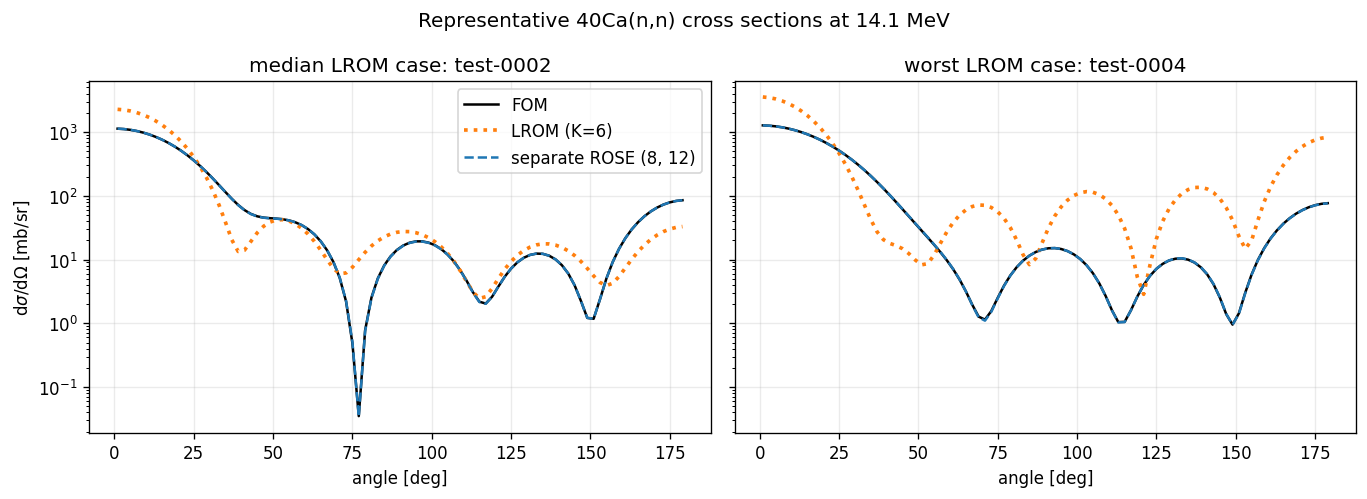

In [6]:
# FIGURE: representative-cross-sections
default_k = K_VALUES[1]
default_rose = ROSE_CONFIGS[-1]
test_errors = lrom_results[default_k]["test_errors"]
median_index = int(np.argsort(test_errors)[len(test_errors) // 2])
worst_index = int(np.argmax(test_errors))

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2), sharey=True)
for ax, index, label in (
    (axes[0], median_index, "median LROM case"),
    (axes[1], worst_index, "worst LROM case"),
):
    ax.semilogy(ANGLES_DEG, fom_test_xs[index], color="black", label="FOM")
    ax.semilogy(ANGLES_DEG, lrom_results[default_k]["test_xs"][index],
                ":", color="tab:orange", lw=2.2, label=f"LROM (K={default_k})")
    ax.semilogy(ANGLES_DEG, rose_results[default_rose]["test_xs"][index],
                "--", color="tab:blue", label=f"separate ROSE {default_rose}")
    ax.set_xlabel("angle [deg]")
    ax.set_title(f"{label}: test-{index:04d}")
axes[0].set_ylabel(r"d$\sigma$/d$\Omega$ [mb/sr]")
axes[0].legend()
fig.suptitle("Representative 40Ca(n,n) cross sections at 14.1 MeV")
fig.tight_layout()
plt.show()

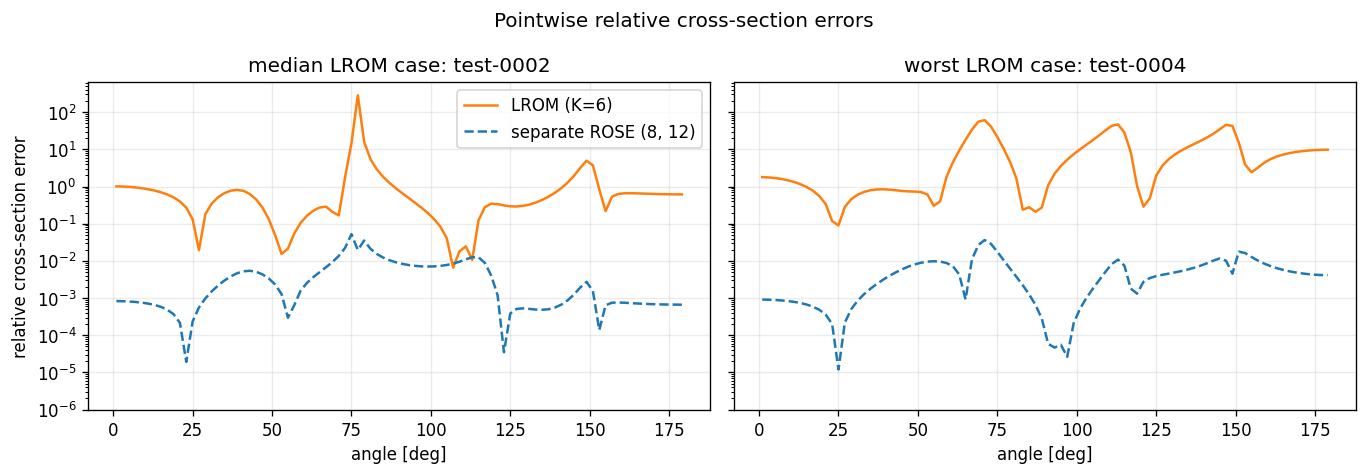

In [7]:
# FIGURE: cross-section-errors
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.0), sharey=True)
for ax, index, label in (
    (axes[0], median_index, "median LROM case"),
    (axes[1], worst_index, "worst LROM case"),
):
    lrom_pointwise = (
        np.abs(lrom_results[default_k]["test_xs"][index] - fom_test_xs[index])
        / np.abs(fom_test_xs[index])
    )
    rose_pointwise = (
        np.abs(rose_results[default_rose]["test_xs"][index] - fom_test_xs[index])
        / np.abs(fom_test_xs[index])
    )
    ax.semilogy(ANGLES_DEG, np.maximum(lrom_pointwise, DIFFERENCE_FLOOR),
                color="tab:orange", label=f"LROM (K={default_k})")
    ax.semilogy(ANGLES_DEG, np.maximum(rose_pointwise, DIFFERENCE_FLOOR),
                "--", color="tab:blue", label=f"separate ROSE {default_rose}")
    ax.set_xlabel("angle [deg]")
    ax.set_ylim(bottom=DIFFERENCE_FLOOR)
    ax.set_title(f"{label}: test-{index:04d}")
axes[0].set_ylabel("relative cross-section error")
axes[0].legend()
fig.suptitle("Pointwise relative cross-section errors")
fig.tight_layout()
plt.show()

## Cross-section error distributions

Split violins in the benchmark_02 style: training distribution on the left
half, testing on the right, medians marked with diamonds, log axis.

ROSE (4, 8)    train median=4.927e-02  test median=9.676e-02
ROSE (8, 12)   train median=6.938e-04  test median=1.687e-03
LROM K=3       train median=3.621e-01  test median=4.773e-01
LROM K=6       train median=3.338e-01  test median=4.945e-01
LROM K=9       train median=3.338e-01  test median=3.299e-01


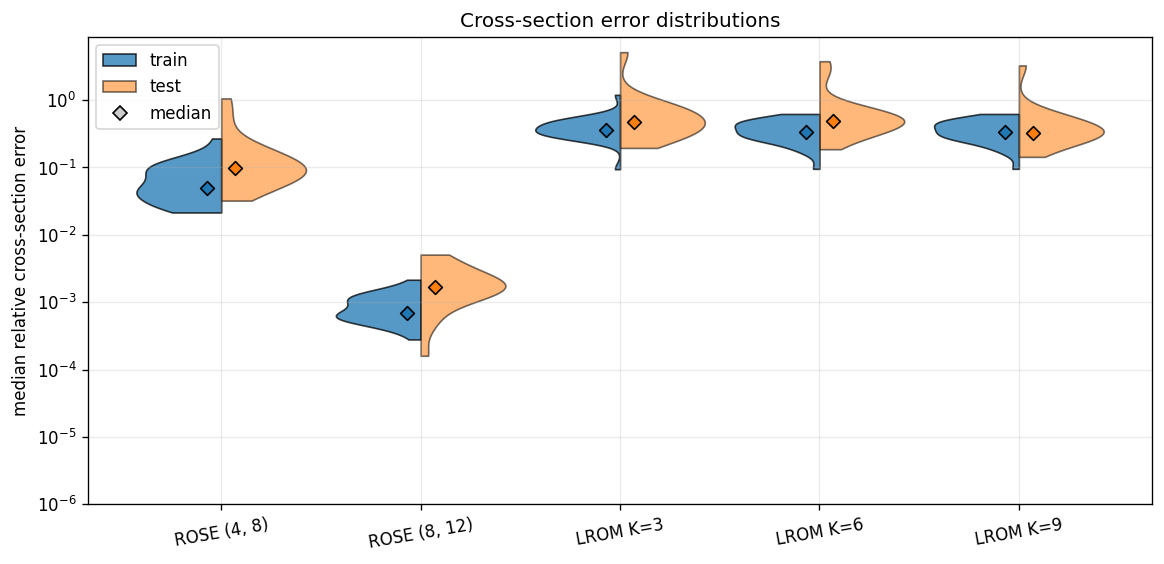

In [8]:
# FIGURE: error-violins
categories = [(f"ROSE {config}", result) for config, result in rose_results.items()]
categories += [(f"LROM K={k}", result) for k, result in lrom_results.items()]
positions = np.arange(1, len(categories) + 1)
floor_power = np.log10(DIFFERENCE_FLOOR)
fig, ax = plt.subplots(figsize=(9.8, 4.8))
for center_pos, (label, result) in zip(positions, categories):
    print(f"{label:<14} train median={np.median(result['train_errors']):.3e}  "
          f"test median={np.median(result['test_errors']):.3e}")
    for side, key, color, alpha in ((-1, "train_errors", "tab:blue", 0.75),
                                    (+1, "test_errors", "tab:orange", 0.55)):
        log_values = np.log10(np.clip(result[key], DIFFERENCE_FLOOR, None))
        parts = ax.violinplot([log_values], positions=[center_pos], widths=0.85, showextrema=False)
        body = parts["bodies"][0]
        vertices = body.get_paths()[0].vertices
        if side < 0:
            vertices[:, 0] = np.minimum(vertices[:, 0], center_pos)
        else:
            vertices[:, 0] = np.maximum(vertices[:, 0], center_pos)
        body.set_facecolor(color)
        body.set_edgecolor("black")
        body.set_alpha(alpha)
        ax.scatter(center_pos + 0.07 * side, np.median(log_values), marker="D", s=34,
                   color=color, edgecolor="black", zorder=6)
ax.set_xticks(positions, [label for label, _ in categories], rotation=10)
ticks = np.arange(int(floor_power), 1)
ax.set_yticks(ticks, [fr"$10^{{{k}}}$" for k in ticks])
ax.set_ylim(bottom=floor_power)
ax.set_ylabel("median relative cross-section error")
ax.set_title("Cross-section error distributions")
ax.legend(handles=[
    Patch(facecolor="tab:blue", alpha=0.75, edgecolor="black", label="train"),
    Patch(facecolor="tab:orange", alpha=0.55, edgecolor="black", label="test"),
    Line2D([], [], marker="D", linestyle="None", markerfacecolor="0.8",
           markeredgecolor="black", label="median"),
])
fig.tight_layout()
plt.show()

## CAT plot

Accuracy versus online time: each point is one configuration at its median
per-sample online evaluation time and its median held-out error. The legacy
notebook's cached point clouds are recreated live with a representative
subset of configurations.

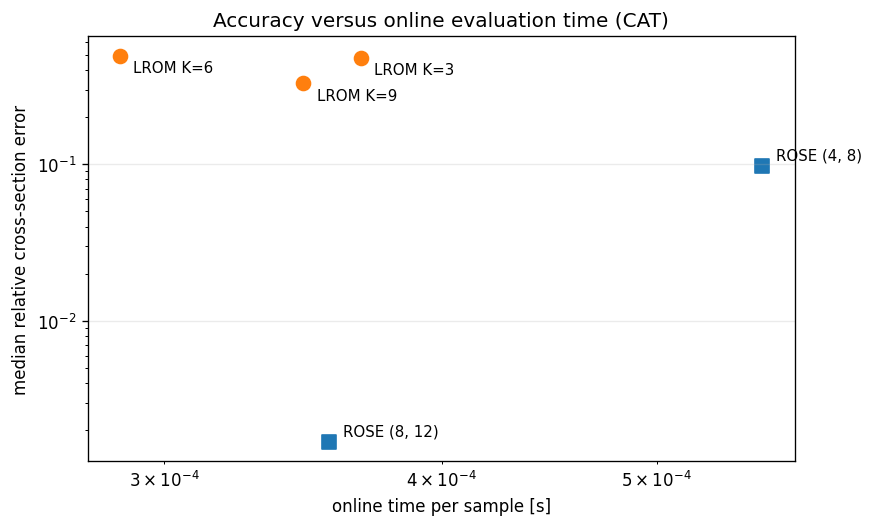

In [9]:
# FIGURE: cat-plot
fig, ax = plt.subplots(figsize=(7.6, 4.6))
for config, result in rose_results.items():
    ax.scatter(result["seconds_per_sample"], np.median(result["test_errors"]),
               marker="s", s=70, color="tab:blue")
    ax.annotate(f"ROSE {config}",
                (result["seconds_per_sample"], np.median(result["test_errors"])),
                textcoords="offset points", xytext=(8, 4), fontsize=9)
for k_predictors, result in lrom_results.items():
    ax.scatter(result["seconds_per_sample"], np.median(result["test_errors"]),
               marker="o", s=70, color="tab:orange")
    ax.annotate(f"LROM K={k_predictors}",
                (result["seconds_per_sample"], np.median(result["test_errors"])),
                textcoords="offset points", xytext=(8, -10), fontsize=9)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("online time per sample [s]")
ax.set_ylabel("median relative cross-section error")
ax.set_title("Accuracy versus online evaluation time (CAT)")
plt.show()

## Summary table

In [10]:
rows = []
for config, result in rose_results.items():
    rows.append({"method": f"ROSE {config}",
                 "median time [s]": result["seconds_per_sample"],
                 "median error": float(np.median(result["test_errors"]))})
for k_predictors, result in lrom_results.items():
    rows.append({"method": f"LROM K={k_predictors}",
                 "median time [s]": result["seconds_per_sample"],
                 "median error": float(np.median(result["test_errors"]))})
pd.DataFrame(rows).set_index("method")

,median time [s],median error
method,,
"ROSE (4, 8)",0.000558,0.096765
"ROSE (8, 12)",0.000356,0.001687
LROM K=3,0.000368,0.477260
LROM K=6,0.000287,0.494548
LROM K=9,0.000347,0.329881


## What to notice

Compare each LROM point against the equal-basis ROSE configurations in both
accuracy and online time: the learned route solves small implicit systems
instead of projecting operators, and its cached assembler makes the online
stage a few small solves plus one cross-section assembly. With the
spin-orbit-aware predictors, the LROM sees all ten optical parameters; the
remaining gap to its own least-squares floor measures the learned
coefficient map, not missing physics.

**Diagnostic addendum (2026-07-15).** Re-running the testing set with
least-squares-projected coefficients — the best any coefficient map could do
in this basis — gives a median cross-section error of 3.6e-1, statistically
identical to the learned LROM's 3.3e-1, while the same LS coefficients give
wavefunction errors of ~1e-3. The cross-section gap to ROSE is therefore a
property of the L2-optimal reduced representation, not of the learned
operators or the predictors: the S-matrix depends on the wavefunction and
its derivative at the matching radius, which an L2 fit does not control.
ROSE's Galerkin projection satisfies the scattering equation weakly and
tracks the asymptotics far better at equal basis size. The 2.x route to
cross-section accuracy is an asymptotics-aware coordinate target (e.g.
matching-region-weighted projection or directly constrained phi(s0),
phi'(s0)), not more predictors.
